# Polymarket DCA Skew Model
**Real data: BTC at \\$78,726, February 1, 2026**

This notebook walks through two approaches to computing a skew score from Polymarket's Bitcoin reach/dip markets, surfaces the key differences, and flags model limitations.

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

SPOT     = 78_726
BASE_DCA = 500  # user's base weekly DCA in USD

# Upside markets: P(Bitcoin reaches $X during the month)
# Source: Polymarket "what-price-will-bitcoin-hit-in-february-2026", sampled at Feb 1 2026 00:00 UTC
upside_touch = {
     85_000: 0.55,
     90_000: 0.27,
     95_000: 0.15,
    100_000: 0.08,
    105_000: 0.053,
    110_000: 0.0355,
    115_000: 0.025,
    120_000: 0.027,   # slightly > $115k — thin liquidity noise
    125_000: 0.0215,
    150_000: 0.0115,
}

# Downside markets: P(Bitcoin dips to $X during the month)
# $80k excluded: strike was above SPOT ($78,726) — already crossed at month open
downside_touch = {
     75_000: 0.675,
     70_000: 0.34,
     65_000: 0.16,
     60_000: 0.09,
     55_000: 0.058,
     50_000: 0.0345,
     45_000: 0.0285,
     40_000: 0.023,
     35_000: 0.021,
}

print(f'Spot: ${SPOT:,}')
print(f'Upside rungs:   {sorted(upside_touch)}')
print(f'Downside rungs: {sorted(downside_touch, reverse=True)}')

Spot: $78,726
Upside rungs:   [85000, 90000, 95000, 100000, 105000, 110000, 115000, 120000, 125000, 150000]
Downside rungs: [75000, 70000, 65000, 60000, 55000, 50000, 45000, 40000, 35000]


## 1. Raw Probabilities

Each ladder is monotone by construction. Visualizing them side by side shows the shape of the crowd's beliefs about upside and downside reach.

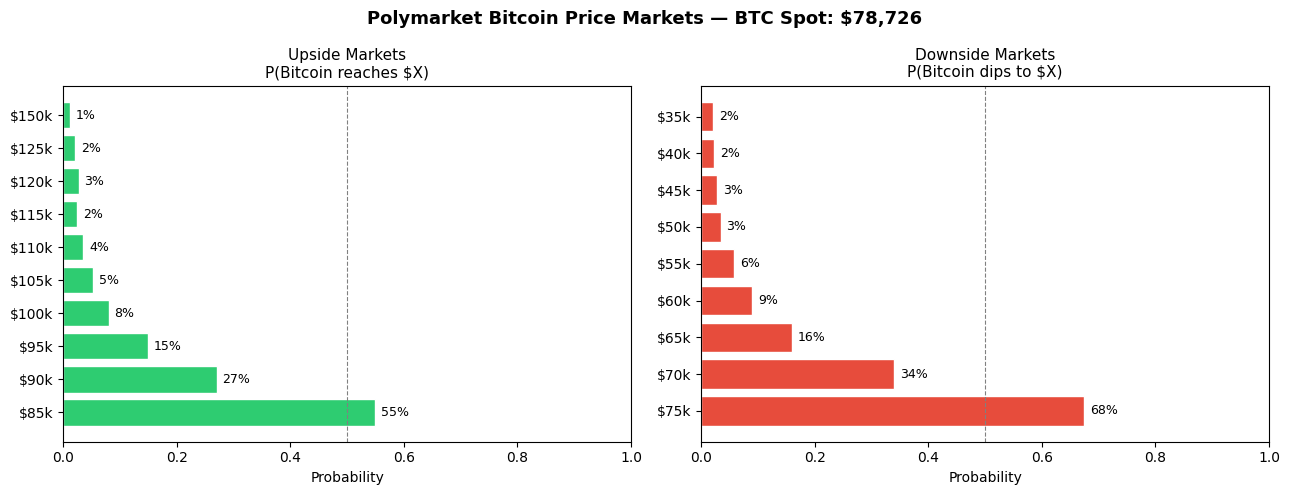

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Upside ---
ax = axes[0]
up_prices = sorted(upside_touch)
up_probs  = [upside_touch[p] for p in up_prices]
bars = ax.barh([f'${p//1000}k' for p in up_prices], up_probs, color='#2ecc71', edgecolor='white')
ax.bar_label(bars, fmt=lambda x: f'{x:.0%}', padding=4, fontsize=9)
ax.set_xlim(0, 1)
ax.set_xlabel('Probability')
ax.set_title('Upside Markets\nP(Bitcoin reaches $X)', fontsize=11)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.8)

# --- Downside ---
ax = axes[1]
dn_prices = sorted(downside_touch, reverse=True)
dn_probs  = [downside_touch[p] for p in dn_prices]
bars = ax.barh([f'${p//1000}k' for p in dn_prices], dn_probs, color='#e74c3c', edgecolor='white')
ax.bar_label(bars, fmt=lambda x: f'{x:.0%}', padding=4, fontsize=9)
ax.set_xlim(0, 1)
ax.set_xlabel('Probability')
ax.set_title('Downside Markets\nP(Bitcoin dips to $X)', fontsize=11)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.8)

fig.suptitle(f'Polymarket Bitcoin Price Markets — BTC Spot: ${SPOT:,}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Recovering Range Masses

Differencing adjacent probabilities gives the probability mass in each price band. Here's the reasoning:

**Why anchor at P = 1.0 for spot?**
Bitcoin is currently trading at \\$78,726. So the probability that it "reaches" \\$78,726 at some point this month is 100% — it already has. This gives us a starting point for the differencing.

**Why does differencing give us range mass?**
Each upside market gives us P(monthly high ≥ \\$X). This is a complementary CDF — it tells us the probability that Bitcoin's peak *at least* reaches each level. Differencing adjacent values peels off the probability that the peak falls *between* two rungs:

```
P(high in $85k–$90k band) = P(high ≥ $85k) − P(high ≥ $90k)
                          = 55% − 27% = 28%
```

In other words: 28% of the time, Bitcoin reaches \\$85k but not \\$90k. That's the probability mass in that band. The same logic applies to the downside ladder, just mirrored.

**The two ladders are independent distributions:**
- The upside ladder models the monthly **high** (maximum price)
- The downside ladder models the monthly **low** (minimum price)

These are different random variables. Bitcoin can have a high of \\$88k *and* a low of \\$68k in the same month — a volatile month with both a rally and a dip. This is why the probability masses across both ladders sum to more than 1.0. Each ladder is internally consistent (sums to 1), but they measure separate things and cannot be merged into a single PDF without additional information about their joint distribution.

In [12]:
def range_masses_upside(touch_probs, spot):
    """P(monthly high falls in each band above spot)."""
    prices = sorted(touch_probs)
    anchor = 1.0  # P(reaches spot) = 1, Bitcoin is already there
    probs  = [anchor] + [touch_probs[p] for p in prices]
    bounds = [spot]  + prices
    result = []
    for i in range(1, len(probs)):
        mass = probs[i-1] - probs[i]
        result.append((bounds[i-1], bounds[i], mass))
    result.append((prices[-1], None, touch_probs[prices[-1]]))  # tail
    return result

def range_masses_downside(touch_probs, spot):
    """P(monthly low falls in each band below spot)."""
    prices = sorted(touch_probs, reverse=True)
    anchor = 1.0  # P(reaches spot) = 1
    probs  = [anchor] + [touch_probs[p] for p in prices]
    bounds = [spot]  + prices
    result = []
    for i in range(1, len(probs)):
        mass = probs[i-1] - probs[i]
        result.append((bounds[i], bounds[i-1], mass))  # (lower, upper, mass)
    result.append((None, prices[-1], touch_probs[prices[-1]]))  # tail
    return result

up_ranges = range_masses_upside(upside_touch, SPOT)
dn_ranges = range_masses_downside(downside_touch, SPOT)

print('Upside range masses (P that monthly HIGH is in this band):')
for lo, hi, mass in up_ranges:
    lo_s = f'${lo:,}' if lo else 'below'
    hi_s = f'${hi:,}' if hi else 'above'
    print(f'  {lo_s} – {hi_s}: {mass:.2%}')

print()
print('Downside range masses (P that monthly LOW is in this band):')
for lo, hi, mass in dn_ranges:
    lo_s = f'${lo:,}' if lo else 'below'
    hi_s = f'${hi:,}' if hi else 'spot'
    print(f'  {lo_s} – {hi_s}: {mass:.2%}')

total = sum(m for *_, m in up_ranges) + sum(m for *_, m in dn_ranges)
print(f'\nTotal mass across both ladders: {total:.2f} (> 1 because they are independent)')

Upside range masses (P that monthly HIGH is in this band):
  $78,726 – $85,000: 45.00%
  $85,000 – $90,000: 28.00%
  $90,000 – $95,000: 12.00%
  $95,000 – $100,000: 7.00%
  $100,000 – $105,000: 2.70%
  $105,000 – $110,000: 1.75%
  $110,000 – $115,000: 1.05%
  $115,000 – $120,000: -0.20%
  $120,000 – $125,000: 0.55%
  $125,000 – $150,000: 1.00%
  $150,000 – above: 1.15%

Downside range masses (P that monthly LOW is in this band):
  $75,000 – $78,726: 32.50%
  $70,000 – $75,000: 33.50%
  $65,000 – $70,000: 18.00%
  $60,000 – $65,000: 7.00%
  $55,000 – $60,000: 3.20%
  $50,000 – $55,000: 2.35%
  $45,000 – $50,000: 0.60%
  $40,000 – $45,000: 0.55%
  $35,000 – $40,000: 0.20%
  below – $35,000: 2.10%

Total mass across both ladders: 2.00 (> 1 because they are independent)


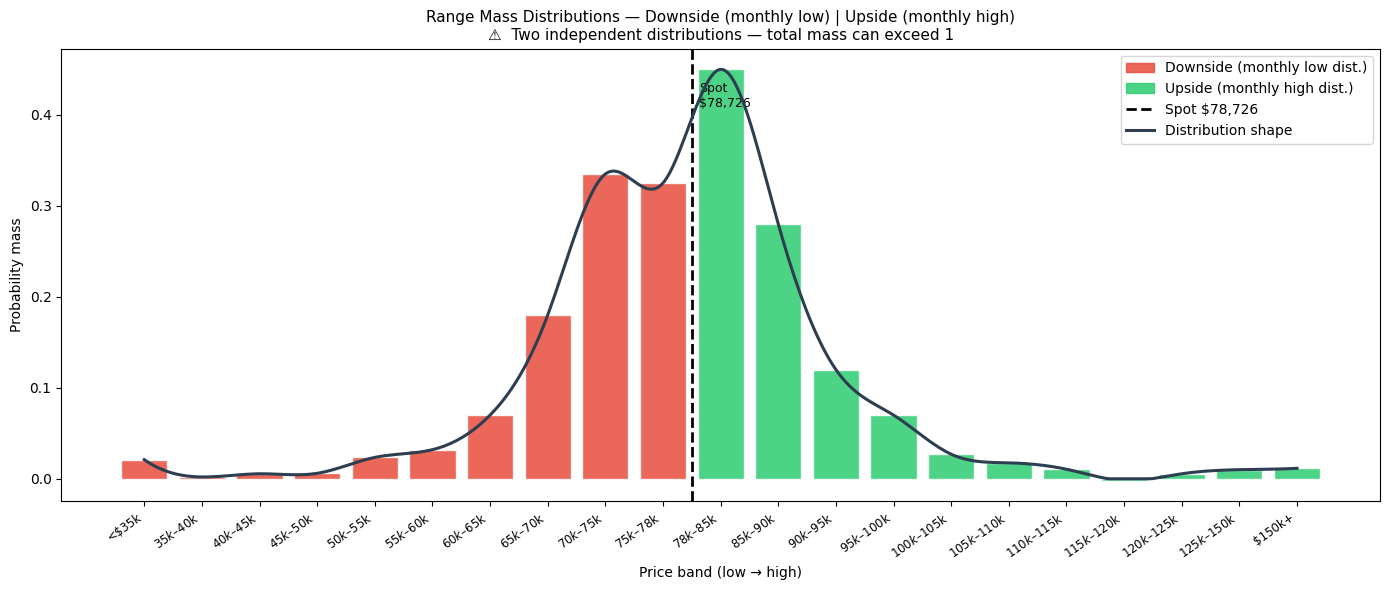

In [13]:
# pip install scipy  (if not already installed)
from scipy.interpolate import make_interp_spline

fig, ax = plt.subplots(figsize=(14, 6))

# Order all bands from lowest to highest price
dn_ordered = list(reversed(dn_ranges))  # reversed so prices go low → high
up_ordered = up_ranges                  # already low → high

def band_label(lo, hi):
    if lo is None:
        return f'<${hi//1000}k'
    if hi is None:
        return f'${lo//1000}k+'
    return f'${lo//1000}k–${hi//1000}k'

all_labels = [band_label(lo, hi) for lo, hi, _ in dn_ordered + up_ordered]
all_masses = [mass for _, _, mass in dn_ordered + up_ordered]
all_colors = ['#e74c3c'] * len(dn_ordered) + ['#2ecc71'] * len(up_ordered)

x = np.arange(len(all_labels), dtype=float)
ax.bar(x, all_masses, color=all_colors, edgecolor='white', width=0.8, alpha=0.85)

# Spot divider: between last downside bar and first upside bar
spot_x = len(dn_ordered) - 0.5
ax.axvline(spot_x, color='black', linestyle='--', linewidth=2)
ax.text(spot_x + 0.12, max(all_masses) * 0.97,
        f'Spot\n${SPOT:,}', fontsize=9, va='top', color='black')

# Cubic spline tracing the shape of the distribution
x_smooth = np.linspace(x[0], x[-1], 400)
spline   = make_interp_spline(x, np.array(all_masses), k=3)
y_smooth = np.clip(spline(x_smooth), 0, None)
ax.plot(x_smooth, y_smooth, color='#2c3e50', linewidth=2.2, zorder=5)

ax.set_xticks(x)
ax.set_xticklabels(all_labels, rotation=35, ha='right', fontsize=8.5)
ax.set_ylabel('Probability mass')
ax.set_xlabel('Price band (low → high)')
ax.set_title(
    'Range Mass Distributions — Downside (monthly low) | Upside (monthly high)\n'
    '⚠  Two independent distributions — total mass can exceed 1',
    fontsize=11
)

dn_patch   = mpatches.Patch(color='#e74c3c', alpha=0.85, label='Downside (monthly low dist.)')
up_patch   = mpatches.Patch(color='#2ecc71', alpha=0.85, label='Upside (monthly high dist.)')
spot_line  = plt.Line2D([0], [0], color='black',   linestyle='--', linewidth=2,   label=f'Spot ${SPOT:,}')
curve_line = plt.Line2D([0], [0], color='#2c3e50', linestyle='-',  linewidth=2.2, label='Distribution shape')
ax.legend(handles=[dn_patch, up_patch, spot_line, curve_line], loc='upper right')

plt.tight_layout()
plt.show()

## 3. Approach A — Naive Ratio

Use only the **innermost rung** on each side — the \\$85k upside rung and the \\$75k downside rung.

$$\text{Skew}_A = \frac{P(\text{reaches } \$85k)}{P(\text{reaches } \$85k) + P(\text{dips to } \$75k)}$$

**Why the innermost rung?**
The markets closest to the current price are the most liquid and carry the strongest signal. Traders are most willing to stake money on near-term, plausible price moves — so the \\$85k and \\$75k markets aggregate far more conviction than, say, the \\$150k market. The innermost rung gives you the clearest read on near-term directional sentiment.

**Why does the ratio work as a sentiment score?**
Recall that these two probabilities come from different distributions (upside high vs. downside low). Strictly speaking, you can't add them into a single probability — they don't compete for the same 100%. But as a *ratio*, they work fine: we're not claiming the result is a probability, we're using it as a normalized sentiment score. If the crowd prices a higher chance of Bitcoin reaching \\$85k than dipping to \\$75k, the ratio exceeds 0.5 and the score is bullish. If the crowd prices more downside, it falls below 0.5. The ratio captures directional lean without pretending to be a rigorous probability.

**A critical flaw with real data — asymmetric rung distances:**
This approach silently assumes the innermost rungs sit at roughly equal distances from spot. With our real data, SPOT = \\$78,726 falls unevenly between the \\$5k grid lines:

- Nearest upside rung: \\$85k — **\\$6,274 away**
- Nearest downside rung: \\$75k — **\\$3,726 away**

P(dips to \\$75k) = 67.5% is high partly because \\$75k is close, not necessarily because the crowd is bearish. Comparing it directly to P(reaches \\$85k) = 55% — a move nearly twice as large — produces a score biased toward downside by geometry alone, not sentiment. Approach C resolves this by weighting every rung by distance, so closer rungs don't automatically dominate.

In [14]:
nearest_up_strike   = min(upside_touch)
nearest_down_strike = max(downside_touch)
nearest_up          = upside_touch[nearest_up_strike]    # P(reaches $85k)
nearest_down        = downside_touch[nearest_down_strike] # P(dips to $75k)

skew_a  = nearest_up / (nearest_up + nearest_down)
score_a = round(skew_a * 100)

print(f'Upside mass   = P(reaches ${nearest_up_strike:,})  = {nearest_up:.0%}')
print(f'Downside mass = P(dips to ${nearest_down_strike:,}) = {nearest_down:.0%}')
print(f'Skew A        = {skew_a:.3f}')
print(f'Score A       = {score_a} / 100')

Upside mass   = P(reaches $85,000)  = 55%
Downside mass = P(dips to $75,000) = 68%
Skew A        = 0.449
Score A       = 45 / 100


## 4. Approach B — Magnitude-Weighted Ratio

Weight each rung by its **distance from spot**. A 10% chance of reaching \\$110k (\\$31k away) is a stronger upside signal than a 10% chance of reaching \\$85k (\\$6k away) — the crowd is expressing conviction about a much larger move.

$$\text{Upside score} = \sum_{\text{upside rungs}} P(\text{reaches rung}) \times (\text{rung} - \text{spot})$$
$$\text{Downside score} = \sum_{\text{downside rungs}} P(\text{dips to rung}) \times (\text{spot} - \text{rung})$$
$$\text{Skew}_B = \frac{\text{Upside score}}{\text{Upside score} + \text{Downside score}}$$

**What does the weighted sum represent?**
Each term `P(rung) × distance` is a contribution to an *implied expected excursion* — roughly, how far does the crowd think Bitcoin will travel in this direction? Summing across all rungs gives a single number that captures both the probability and the magnitude of directional moves. A market where everyone thinks Bitcoin will reach \\$110k contributes far more to the upside score than one where they only expect \\$85k.

**Why normalize with the ratio?**
The upside and downside scores are in dollar units (probability × dollars), so they're not directly interpretable as probabilities. Dividing by their sum squashes the result back to a 0–1 scale: 0.5 = balanced, >0.5 = crowd expects more upside reach, <0.5 = more downside reach.

**The asymmetry flaw:**
The upside ladder extends to \\$150k (+\\$71k from spot). The downside ladder only goes to \\$35k (−\\$44k from spot). Even at tiny probabilities, that extra \\$27k of upside range contributes weighted mass that the downside ladder structurally cannot match. The score will lean bullish simply because Polymarket happened to list a \\$150k market — not because the crowd is genuinely more bullish. Approach C addresses this.

In [15]:
up_contributions   = {p: prob * (p - SPOT) for p, prob in upside_touch.items()}
down_contributions = {p: prob * (SPOT - p) for p, prob in downside_touch.items()}

upside_score   = sum(up_contributions.values())
downside_score = sum(down_contributions.values())

skew_b = upside_score / (upside_score + downside_score)
score_b = round(skew_b * 100)

print('Upside contributions (prob × distance from spot):')
for p, v in sorted(up_contributions.items()):
    print(f'  ${p:,}: {upside_touch[p]:.0%} × ${p-SPOT:,} = ${v:,.0f}')
print(f'  Total upside score: ${upside_score:,.0f}')

print()
print('Downside contributions (prob × distance from spot):')
for p, v in sorted(down_contributions.items(), reverse=True):
    print(f'  ${p:,}: {downside_touch[p]:.0%} × ${SPOT-p:,} = ${v:,.0f}')
print(f'  Total downside score: ${downside_score:,.0f}')

print(f'\nSkew B  = {upside_score:,.0f} / ({upside_score:,.0f} + {downside_score:,.0f}) = {skew_b:.3f}')
print(f'Score B = {score_b} / 100')

Upside contributions (prob × distance from spot):
  $85,000: 55% × $6,274 = $3,451
  $90,000: 27% × $11,274 = $3,044
  $95,000: 15% × $16,274 = $2,441
  $100,000: 8% × $21,274 = $1,702
  $105,000: 5% × $26,274 = $1,393
  $110,000: 4% × $31,274 = $1,110
  $115,000: 2% × $36,274 = $907
  $120,000: 3% × $41,274 = $1,114
  $125,000: 2% × $46,274 = $995
  $150,000: 1% × $71,274 = $820
  Total upside score: $16,976

Downside contributions (prob × distance from spot):
  $75,000: 68% × $3,726 = $2,515
  $70,000: 34% × $8,726 = $2,967
  $65,000: 16% × $13,726 = $2,196
  $60,000: 9% × $18,726 = $1,685
  $55,000: 6% × $23,726 = $1,376
  $50,000: 3% × $28,726 = $991
  $45,000: 3% × $33,726 = $961
  $40,000: 2% × $38,726 = $891
  $35,000: 2% × $43,726 = $918
  Total downside score: $14,501

Skew B  = 16,976 / (16,976 + 14,501) = 0.539
Score B = 54 / 100


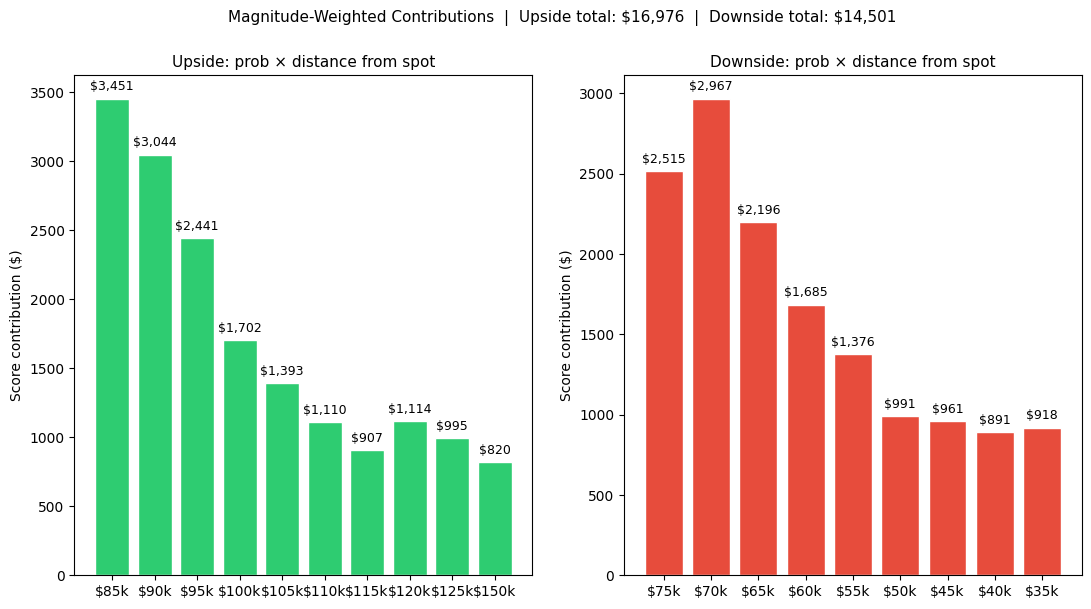

In [16]:
# Visualize the magnitude-weighted contributions
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))

ax = axes[0]
up_prices  = sorted(up_contributions)
up_vals    = [up_contributions[p] for p in up_prices]
bars = ax.bar([f'${p//1000}k' for p in up_prices], up_vals, color='#2ecc71', edgecolor='white')
ax.bar_label(bars, fmt=lambda x: f'${x:,.0f}', padding=4, fontsize=9)
ax.set_title('Upside: prob × distance from spot', fontsize=11)
ax.set_ylabel('Score contribution ($)')

ax = axes[1]
dn_prices  = sorted(down_contributions, reverse=True)
dn_vals    = [down_contributions[p] for p in dn_prices]
bars = ax.bar([f'${p//1000}k' for p in dn_prices], dn_vals, color='#e74c3c', edgecolor='white')
ax.bar_label(bars, fmt=lambda x: f'${x:,.0f}', padding=4, fontsize=9)
ax.set_title('Downside: prob × distance from spot', fontsize=11)
ax.set_ylabel('Score contribution ($)')

fig.suptitle(f'Magnitude-Weighted Contributions  |  Upside total: \\${upside_score:,.0f}  |  Downside total: \\${downside_score:,.0f}',
             fontsize=11)
plt.subplots_adjust(top=0.88)
plt.show()

## 5. Comparison & DCA Recommendation

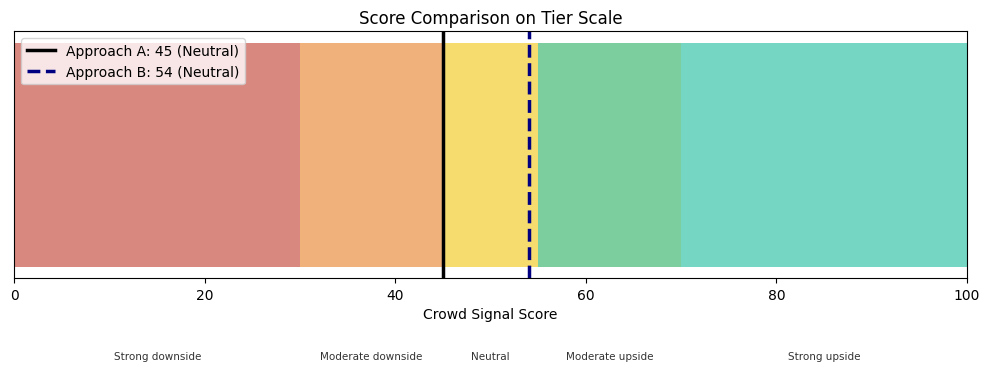


  Approach A → Score 45 → Neutral → 1.0x multiplier → DCA: $500
  Approach B → Score 54 → Neutral → 1.0x multiplier → DCA: $500
  Base DCA: $500


In [17]:
TIERS = [
    (70, 100, 'Strong upside',    2.0),
    (55,  70, 'Moderate upside',  1.25),
    (45,  55, 'Neutral',          1.0),
    (30,  45, 'Moderate downside',0.75),
    (  0, 30, 'Strong downside',  0.5),
]

def classify(score):
    for lo, hi, label, mult in TIERS:
        if lo <= score <= hi:
            return label, mult
    return 'Unknown', 1.0

label_a, mult_a = classify(score_a)
label_b, mult_b = classify(score_b)

fig, ax = plt.subplots(figsize=(10, 4))

# Score gauge bar
tier_colors = ['#c0392b', '#e67e22', '#f1c40f', '#27ae60', '#1abc9c']
boundaries  = [0, 30, 45, 55, 70, 100]
for i in range(len(boundaries) - 1):
    ax.barh(0, boundaries[i+1] - boundaries[i], left=boundaries[i],
            color=tier_colors[i], height=0.4, alpha=0.6)

# Score markers
ax.axvline(score_a, color='black',  linewidth=2.5, linestyle='-',  label=f'Approach A: {score_a} ({label_a})')
ax.axvline(score_b, color='navy',   linewidth=2.5, linestyle='--', label=f'Approach B: {score_b} ({label_b})')

ax.set_xlim(0, 100)
ax.set_yticks([])
ax.set_xlabel('Crowd Signal Score')
ax.set_title('Score Comparison on Tier Scale', fontsize=12)
ax.legend(loc='upper left')
for lo, hi, label, _ in TIERS:
    ax.text((lo + hi) / 2, -0.35, label, ha='center', va='top', fontsize=7.5, color='#333')

plt.tight_layout()
plt.show()

print(f'\n  Approach A → Score {score_a} → {label_a} → {mult_a}x multiplier → DCA: ${BASE_DCA * mult_a:,.0f}')
print(f'  Approach B → Score {score_b} → {label_b} → {mult_b}x multiplier → DCA: ${BASE_DCA * mult_b:,.0f}')
print(f'  Base DCA: ${BASE_DCA}')

## 6. Model Limitations

| # | Limitation | Severity | Notes |
|---|------------|----------|-------|
| 1 | **Independence assumption** — two ladders measure HIGH and LOW separately, not a joint distribution. Bitcoin can reach \\$85k and dip to \\$75k in the same month. | Medium | Defensible as a sentiment ratio, not a probability statement. |
| 2 | **Coarse rungs** (\\$5k spacing) — score is sensitive to exactly where spot sits within a \\$5k band. | Low–Medium | Interpolation between rungs could smooth this. |
| 3 | **Range asymmetry** (Approach B only) — upside ladder extends to \\$150k (+\\$71k from spot); downside to \\$35k (−\\$44k from spot). Magnitude-weighting rewards upside simply because the ladder is longer, not because of genuine sentiment. | Medium | Fix: cap both ladders at equal distance from spot before weighting. |
| 4 | **No joint probability** — can't extract P(reaches up AND dips down) from these markets. A high-volatility month where Bitcoin goes +20% then -30% looks different than a low-volatility month that stays flat. | Low | P(both) is small early in the month; acceptable to ignore. |
| 5 | **Thin liquidity at outer rungs** — markets above \\$110k show non-monotone probabilities (e.g. \\$120k priced slightly higher than \\$115k) due to sparse trading. These rungs carry little reliable signal. | Low–Medium | Approach C's distance cap naturally excludes most of these. |
| 6 | **Asymmetric rung distances** (Approach A only) — when SPOT falls unevenly between \\$5k grid lines, the nearest upside and downside rungs are at different distances. With SPOT = \\$78,726, \\$75k is \\$3.7k away vs \\$6.3k to \\$85k. Approach A treats them as equivalent, producing a score biased by geometry rather than sentiment. | High | This makes Approach A unreliable whenever spot is not near a grid midpoint. Approaches B and C are immune since they weight by distance explicitly. |

## 7. Proposed Fix for Limitation 3 — Distance-Capped Weighting

Cap both ladders at the same maximum distance from spot before weighting.

**Why is the asymmetry a real problem, not just theoretical?**
In our data, the \\$150k rung contributes approximately \\$820 to the upside score (1.15% × \\$71,274). That single distant rung outweighs more informative near-spot rungs simply because of ladder length. If Polymarket adds a \\$200k market tomorrow with a 0.1% probability, the upside score jumps by \\$121 with no change in genuine sentiment. The score should not be sensitive to which rungs Polymarket chose to list.

**How capping fixes it:**
By only including rungs within `MAX_DIST` of spot on *both* sides, we ensure the comparison is symmetric. If the furthest upside rung included is \\$109k (+\\$30k), then the furthest downside rung included is \\$49k (−\\$30k). Both sides are evaluated over the same price range, so differences in the score reflect genuine crowd sentiment rather than ladder construction.

**The trade-off:**
Capping discards real signal. If the crowd genuinely believes Bitcoin has a 5% chance of hitting \\$120k this month, and you cap at \\$30k, that conviction disappears from your score. `MAX_DIST` is therefore a tunable parameter — a judgment call about how far out to trust the markets. A reasonable heuristic: set it to the distance of the 2nd or 3rd upside rung, where liquidity and conviction are still meaningful. Rungs beyond that tend to be thinly traded and noisy — as seen in this month's data above \\$110k.

In [18]:
# Symmetric cap: only use rungs within MAX_DIST of spot on each side
MAX_DIST = 30_000  # $30k in either direction

up_capped   = {p: prob for p, prob in upside_touch.items()  if (p - SPOT) <= MAX_DIST}
down_capped = {p: prob for p, prob in downside_touch.items() if (SPOT - p) <= MAX_DIST}

up_score_capped   = sum(prob * (p - SPOT) for p, prob in up_capped.items())
down_score_capped = sum(prob * (SPOT - p) for p, prob in down_capped.items())

skew_c  = up_score_capped / (up_score_capped + down_score_capped)
score_c = round(skew_c * 100)
label_c, mult_c = classify(score_c)

print(f'Upside rungs used  (within ${MAX_DIST:,} of spot): {sorted(up_capped)}')
print(f'Downside rungs used (within ${MAX_DIST:,} of spot): {sorted(down_capped, reverse=True)}')
print()
print(f'Skew C  = {skew_c:.3f}  (distance-capped weighted)')
print(f'Score C = {score_c}')
print(f'Tier    = {label_c}  ({mult_c}x)  → DCA: ${BASE_DCA * mult_c:,.0f}')
print()
print('Summary:')
print(f'  A (naive, innermost rung only):        skew={skew_a:.3f}  score={score_a}')
print(f'  B (full ladder, magnitude-weighted):   skew={skew_b:.3f}  score={score_b}')
print(f'  C (capped ladder, magnitude-weighted): skew={skew_c:.3f}  score={score_c}')

Upside rungs used  (within $30,000 of spot): [85000, 90000, 95000, 100000, 105000]
Downside rungs used (within $30,000 of spot): [75000, 70000, 65000, 60000, 55000, 50000]

Skew C  = 0.506  (distance-capped weighted)
Score C = 51
Tier    = Neutral  (1.0x)  → DCA: $500

Summary:
  A (naive, innermost rung only):        skew=0.449  score=45
  B (full ladder, magnitude-weighted):   skew=0.539  score=54
  C (capped ladder, magnitude-weighted): skew=0.506  score=51


## 8. Approach D — Log-Space Distance Weighting

*Motivated by feedback from a quant reviewer. See `ethan_feedback.md`, Section 4 for full rationale.*

Approach C weights each rung by its **raw dollar distance** from spot. This is financially imprecise. Assets like Bitcoin follow approximately **log-normal dynamics**: what matters is the *percentage* move, not the absolute dollar move. A \\$10k swing from a \\$20k spot (50% move) is a very different signal than the same \\$10k from an \\$80k spot (12.5% move). Raw dollar weighting treats them identically.

The fix is to replace dollar distance with **log-distance**:

$$\text{distance}(K) = \left| \ln\!\left(\frac{K}{\text{spot}}\right) \right|$$

This quantity is the continuously compounded return needed to reach strike \\$K from spot — exactly what log-normal models use to measure "how far away" a level is.

---

### Understanding the log cap: `LOG_CAP = ln(1.40)`

We still cap the ladder to exclude thin, noisy outer rungs — but the cap is now in log-space rather than dollar-space.

**What `ln(1.40)` means:**

`ln(1.40)` is the log-distance of any strike that sits exactly **40% above spot**. More precisely:

$$\ln\!\left(\frac{\text{spot} \times 1.40}{\text{spot}}\right) = \ln(1.40) \approx 0.336$$

So `LOG_CAP = ln(1.40)` means: *include only rungs within a factor of 1.40 from spot on each side.*

**The two boundaries in dollar terms** (with spot = \\$78,726):

| Side | Formula | Result | Rungs included |
|------|---------|--------|----------------|
| Upside | spot × 1.40 | \\$110,216 | \\$85k, \\$90k, \\$95k, \\$100k, \\$105k, \\$110k |
| Downside | spot ÷ 1.40 | \\$56,233 | \\$75k, \\$70k, \\$65k, \\$60k |

Notice the downside boundary is *spot divided by* 1.40, not *spot minus* 40%. That is what makes the cap symmetric in log-space: going up by a factor of 1.40 and coming down by a factor of 1.40 are mirror images in a log-normal world, even though the dollar distances differ (\\$31k up vs \\$22k down).

**Why 1.40 specifically?**

It is a judgment call based on where liquidity drops off in this dataset. Looking at the raw probabilities, markets above \\$110k show non-monotone pricing (e.g. \\$120k priced above \\$115k), a sign of thin trading and unreliable signal. A factor of 1.40 captures the six most liquid upside rungs and four most liquid downside rungs, and excludes the noisy tail. As more monthly data is collected, this threshold can be calibrated empirically.

**Why this also fixes the ladder asymmetry from Approach B/C:**

| Extreme rung | Raw distance from spot | Log-distance |
|---|---|---|
| Upside \\$150k | \\$71,274 | 0.645 |
| Downside \\$35k | \\$43,726 | 0.811 |

Raw dollar extent: **62% wider** on the upside. Log-space extent: only **26% wider** on the downside — and that excess is mostly the thinly-traded outer rungs the cap excludes anyway. The log cap enforces genuine symmetry without needing to manually tune a dollar threshold.

---

**The formula:**

$$\text{Upside score} = \sum_{\substack{\text{upside rungs} \\ \ln(K/\text{spot}) \leq \text{cap}}} P(\text{reaches } K) \times \ln\!\left(\frac{K}{\text{spot}}\right)$$

$$\text{Downside score} = \sum_{\substack{\text{downside rungs} \\ \ln(\text{spot}/K) \leq \text{cap}}} P(\text{dips to } K) \times \ln\!\left(\frac{\text{spot}}{K}\right)$$

$$\text{Skew}_D = \frac{\text{Upside score}}{\text{Upside score} + \text{Downside score}}$$

In [ ]:
LOG_CAP = np.log(1.40)  # ±40% move in log-space (~ln(1.40) ≈ 0.336)

up_log   = {p: prob for p, prob in upside_touch.items()
            if np.log(p / SPOT) <= LOG_CAP}
down_log = {p: prob for p, prob in downside_touch.items()
            if np.log(SPOT / p) <= LOG_CAP}

up_contributions_log   = {p: prob * np.log(p / SPOT)   for p, prob in up_log.items()}
down_contributions_log = {p: prob * np.log(SPOT / p)   for p, prob in down_log.items()}

up_score_log   = sum(up_contributions_log.values())
down_score_log = sum(down_contributions_log.values())

skew_d  = up_score_log / (up_score_log + down_score_log)
score_d = round(skew_d * 100)
label_d, mult_d = classify(score_d)

print(f'LOG_CAP = ln(1.40) = {LOG_CAP:.3f}  (~±40% from spot)\n')

print('Upside rungs used (log-distance ≤ cap):')
for p, v in sorted(up_contributions_log.items()):
    print(f'  ${p:,}: {up_log[p]:.0%} × ln({p:,}/{SPOT:,}) = {np.log(p/SPOT):.3f}  →  contribution {v:.4f}')
print(f'  Total upside log-score: {up_score_log:.4f}')

print()
print('Downside rungs used (log-distance ≤ cap):')
for p, v in sorted(down_contributions_log.items(), reverse=True):
    print(f'  ${p:,}: {down_log[p]:.0%} × ln({SPOT:,}/{p:,}) = {np.log(SPOT/p):.3f}  →  contribution {v:.4f}')
print(f'  Total downside log-score: {down_score_log:.4f}')

print(f'\nSkew D  = {skew_d:.3f}  (log-space distance-capped weighted)')
print(f'Score D = {score_d}')
print(f'Tier    = {label_d}  ({mult_d}x)  → DCA: ${BASE_DCA * mult_d:,.0f}')

print('\n--- Summary: all approaches ---')
print(f'  A (naive, innermost rung):             skew={skew_a:.3f}  score={score_a}  → ${BASE_DCA * mult_a:,.0f}')
print(f'  B (full ladder, dollar-weighted):      skew={skew_b:.3f}  score={score_b}  → ${BASE_DCA * mult_b:,.0f}')
print(f'  C (dollar cap, dollar-weighted):       skew={skew_c:.3f}  score={score_c}  → ${BASE_DCA * mult_c:,.0f}')
print(f'  D (log cap, log-weighted) ← preferred: skew={skew_d:.3f}  score={score_d}  → ${BASE_DCA * mult_d:,.0f}')

In [ ]:
cap_up_price = SPOT * np.exp(LOG_CAP)   # spot × 1.40  ≈ $110,216
cap_dn_price = SPOT * np.exp(-LOG_CAP)  # spot ÷ 1.40  ≈ $56,233

fig = plt.figure(figsize=(14, 9))
gs  = fig.add_gridspec(2, 2, height_ratios=[3, 1], hspace=0.6, wspace=0.35)
ax_up    = fig.add_subplot(gs[0, 0])
ax_dn    = fig.add_subplot(gs[0, 1])
ax_gauge = fig.add_subplot(gs[1, :])

def draw_ladder_panel(ax, prices_dict, contrib_dict, included_set, side, cap_label):
    """
    For each rung, draw two side-by-side bars:
      - Left bar (faded):  raw Polymarket probability  — what the market prices
      - Right bar (solid): prob × log-distance          — the weight used in Approach D
    Excluded rungs (beyond the log cap) are drawn in gray with no contribution bar.
    """
    prices  = sorted(prices_dict) if side == 'up' else sorted(prices_dict, reverse=True)
    clr_inc = '#2ecc71' if side == 'up' else '#e74c3c'

    max_prob = max(prices_dict.values())
    max_contrib = max(contrib_dict.values()) if contrib_dict else 0
    y_top = max(max_prob, max_contrib) * 1.12

    for i, p in enumerate(prices):
        prob    = prices_dict[p]
        contrib = contrib_dict.get(p, 0)
        included = p in included_set
        clr = clr_inc if included else '#cccccc'
        # raw probability (faded)
        ax.bar(i - 0.22, prob,    width=0.4, color=clr, alpha=0.35, edgecolor='none', zorder=2)
        # log-weighted contribution (solid)
        if included:
            ax.bar(i + 0.22, contrib, width=0.4, color=clr, alpha=1.0,  edgecolor='none', zorder=2)

    # Cap boundary vertical line
    first_excl_i = next((i for i, p in enumerate(prices) if p not in included_set), None)
    if first_excl_i is not None:
        bx = first_excl_i - 0.5
        ax.axvline(bx, color='steelblue', linestyle='--', linewidth=1.8, zorder=3)
        ax.text(bx + 0.08, y_top * 0.78, cap_label,
                color='steelblue', fontsize=8, va='top')

    ax.set_xticks(range(len(prices)))
    ax.set_xticklabels([f'\\${p//1000}k' for p in prices],
                       rotation=30, ha='right', fontsize=9)
    ax.set_ylim(0, y_top)
    ax.grid(axis='y', alpha=0.25)

# --- Upside panel ---
draw_ladder_panel(ax_up, upside_touch, up_contributions_log, up_log, 'up',
                  f'Cap: spot × 1.40\n≈ \\${cap_up_price:,.0f}')
ax_up.set_title('Upside rungs', fontsize=11)
ax_up.set_ylabel('Value')

prob_patch_up   = mpatches.Patch(color='#2ecc71', alpha=0.35, label='P(reaches K)  — raw probability')
contrib_patch_up = mpatches.Patch(color='#2ecc71', alpha=1.0,  label='P × ln(K / spot)  — log-weighted contribution')
excl_patch      = mpatches.Patch(color='#cccccc', alpha=0.6,  label='Excluded (beyond log cap)')
ax_up.legend(handles=[prob_patch_up, contrib_patch_up, excl_patch], fontsize=8, loc='upper right')

# --- Downside panel ---
draw_ladder_panel(ax_dn, downside_touch, down_contributions_log, down_log, 'down',
                  f'Cap: spot ÷ 1.40\n≈ \\${cap_dn_price:,.0f}')
ax_dn.set_title('Downside rungs', fontsize=11)

prob_patch_dn    = mpatches.Patch(color='#e74c3c', alpha=0.35, label='P(dips to K)  — raw probability')
contrib_patch_dn = mpatches.Patch(color='#e74c3c', alpha=1.0,  label='P × ln(spot / K)  — log-weighted contribution')
ax_dn.legend(handles=[prob_patch_dn, contrib_patch_dn, excl_patch], fontsize=8, loc='upper right')

# --- Score gauge ---
tier_colors = ['#c0392b', '#e67e22', '#f1c40f', '#27ae60', '#1abc9c']
boundaries  = [0, 30, 45, 55, 70, 100]
for i in range(len(boundaries) - 1):
    ax_gauge.barh(0, boundaries[i+1] - boundaries[i], left=boundaries[i],
                  color=tier_colors[i], height=0.4, alpha=0.6)

ax_gauge.axvline(score_c, color='navy',  linewidth=2,   linestyle='--',
                 label=f'Approach C (dollar cap, dollar-weighted): {score_c}')
ax_gauge.axvline(score_d, color='black', linewidth=2.5, linestyle='-',
                 label=f'Approach D (log cap, log-weighted): {score_d}  ← preferred')

ax_gauge.set_xlim(0, 100)
ax_gauge.set_yticks([])
ax_gauge.set_xlabel('Crowd Signal Score')
ax_gauge.set_title('Resulting score', fontsize=11)
ax_gauge.legend(loc='upper left', fontsize=9)
for lo, hi, label, _ in TIERS:
    ax_gauge.text((lo + hi) / 2, -0.35, label, ha='center', va='top', fontsize=7.5, color='#333')

fig.suptitle(
    f'Approach D — Log-Space Weighting  |  '
    f'Upside log-score: {up_score_log:.3f}  |  '
    f'Downside log-score: {down_score_log:.3f}  |  '
    f'Skew D: {skew_d:.3f}  →  Score: {score_d}',
    fontsize=11, fontweight='bold'
)
plt.show()